In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [1]:
import glob
import json
from pathlib import Path

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

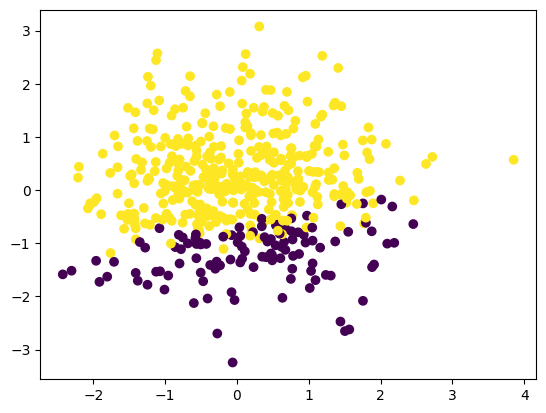

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [2]:
# Prepare datasets, learning rates, and output folders
learning_rates = [0.1, 0.01, 0.001]
dataset_files = sorted(glob.glob('data/logistic_data/logistic_data_*.npz'))

result_dir = Path('result')
plot_dir = result_dir / 'plots' / 'logistic'
metric_dir = result_dir / 'metrics'
result_dir.mkdir(exist_ok=True)
plot_dir.mkdir(exist_ok=True)
metric_dir.mkdir(exist_ok=True)

all_results = {}

print(f"Found {len(dataset_files)} logistic datasets")
print(f"Learning rates: {learning_rates}")
print(f"Results will be saved under: {result_dir.resolve()}")

Found 4 logistic datasets
Learning rates: [0.1, 0.01, 0.001]
Results will be saved under: D:\Workspace\NYCU\Data Mining\DM_CODE\DM2026-Assignment-1\result



Processing logistic_data_A (size=2000, dim=2)
50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.3186543688258759, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.29183663203624455
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.22467783764966348, Val loss:0.2455615161221097
350. Training loss: 0.21624915555159707, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419928, Val loss:0.23190816484103666
450. Training loss: 0.2043156331315366, Val loss:0.22708432494974984
500. Training loss: 0.19991967899618932, Val loss:0.2231158675900225


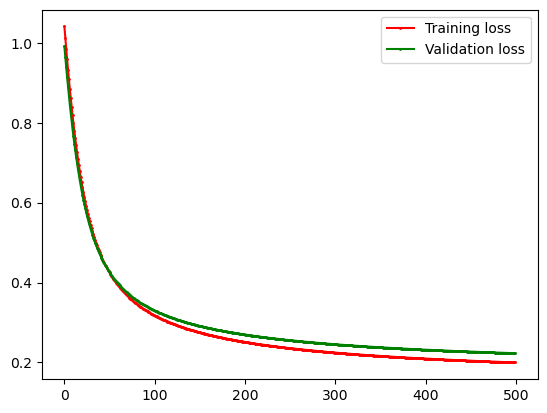

logistic_data_A - Learning Rate: 0.1
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


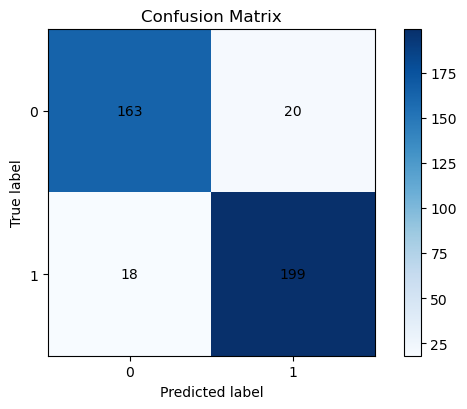

Saved confusion matrix to: result\plots\logistic\logistic_data_A_lr_0.1_confusion_matrix.png


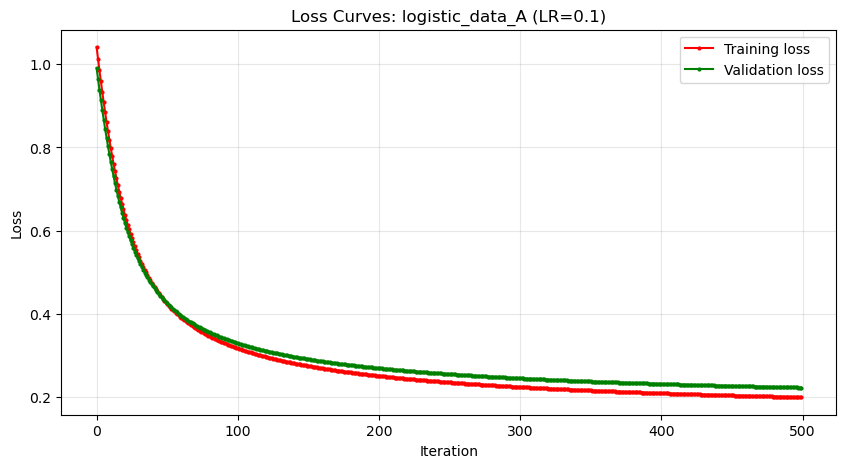

Saved loss curve to: result\plots\logistic\logistic_data_A_lr_0.1_loss_curve.png


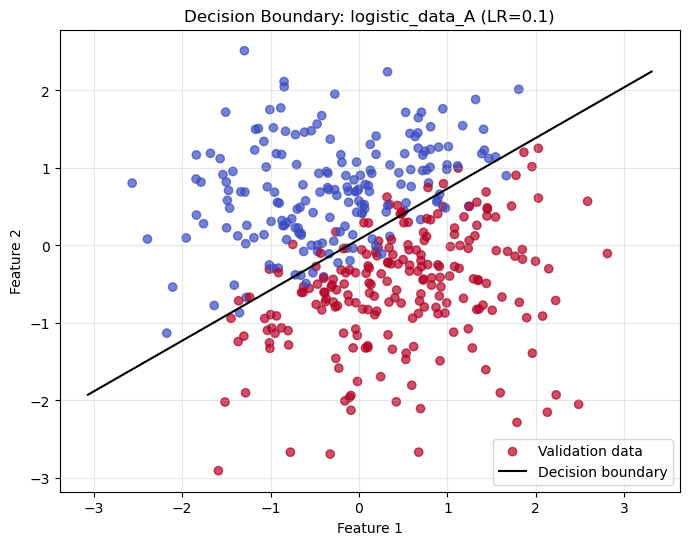

Saved decision boundary to: result\plots\logistic\logistic_data_A_lr_0.1_decision_boundary.png
50. Training loss: 0.9117697645477548, Val loss:0.8909436605779335
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
150. Training loss: 0.7134127241759745, Val loss:0.700717653642279
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163958
250. Training loss: 0.5851379734874116, Val loss:0.5790315939113777
300. Training loss: 0.5394700517290799, Val loss:0.536090659945112
350. Training loss: 0.502528798587891, Val loss:0.5015278107602668
400. Training loss: 0.472286903656601, Val loss:0.4733528541640399
450. Training loss: 0.4472015131236836, Val loss:0.45006424591042526
500. Training loss: 0.42611745469430745, Val loss:0.43054684173876917


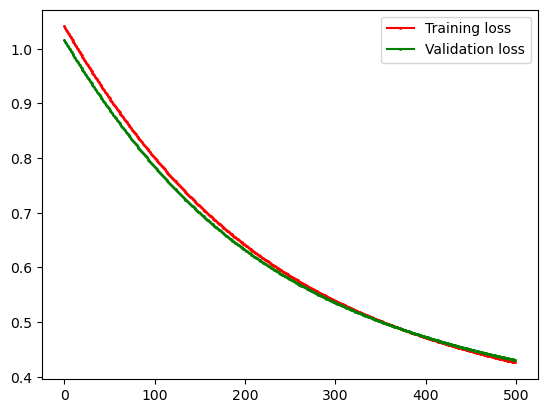

logistic_data_A - Learning Rate: 0.01
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


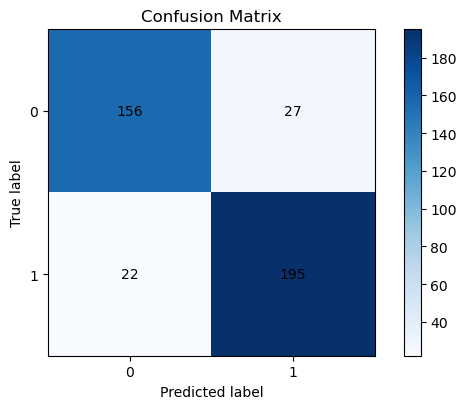

Saved confusion matrix to: result\plots\logistic\logistic_data_A_lr_0.01_confusion_matrix.png


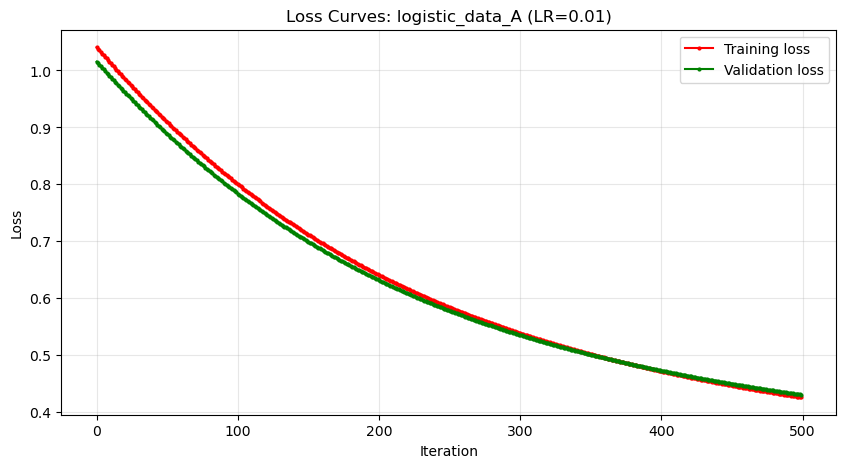

Saved loss curve to: result\plots\logistic\logistic_data_A_lr_0.01_loss_curve.png


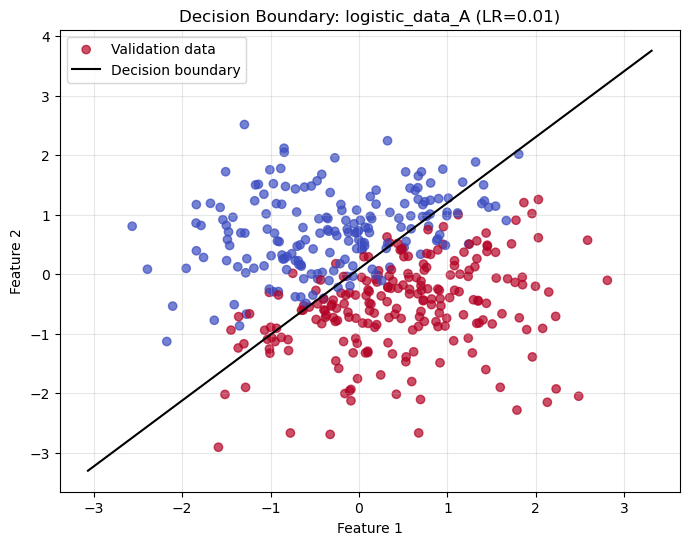

Saved decision boundary to: result\plots\logistic\logistic_data_A_lr_0.01_decision_boundary.png
50. Training loss: 1.0269460601586051, Val loss:1.0044831492028101
100. Training loss: 1.0129964397614701, Val loss:0.9909719737552948
150. Training loss: 0.9992783487558338, Val loss:0.9776880822134313
200. Training loss: 0.9857916009817304, Val loss:0.9646313599916956
250. Training loss: 0.9725358539101563, Val loss:0.9518015338881938
300. Training loss: 0.9595106080951762, Val loss:0.9391981713655225
350. Training loss: 0.9467152071471594, Val loss:0.9268206803770205
400. Training loss: 0.9341488382362758, Val loss:0.9146683097467531
450. Training loss: 0.921810533131396, Val loss:0.9027401501073221
500. Training loss: 0.909699169775372, Val loss:0.8910351353952264


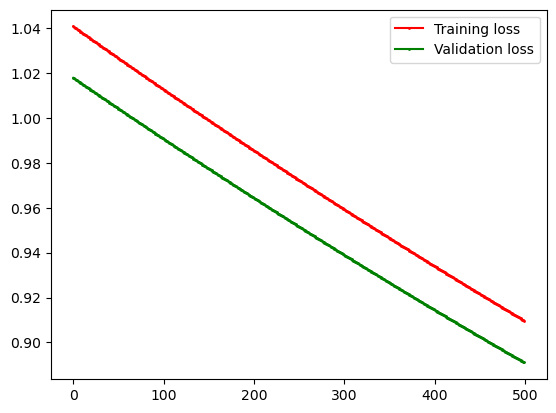

logistic_data_A - Learning Rate: 0.001
Accuracy  : 0.3875
Precision : 0.4364
Recall    : 0.4424
F1-score  : 0.4394


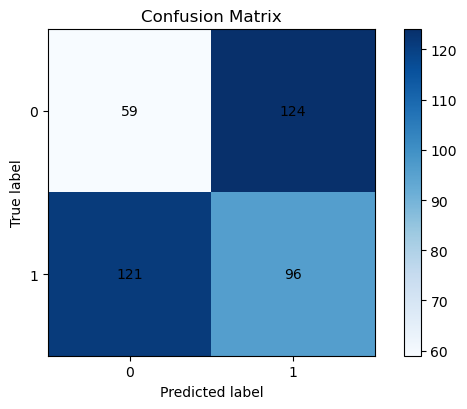

Saved confusion matrix to: result\plots\logistic\logistic_data_A_lr_0.001_confusion_matrix.png


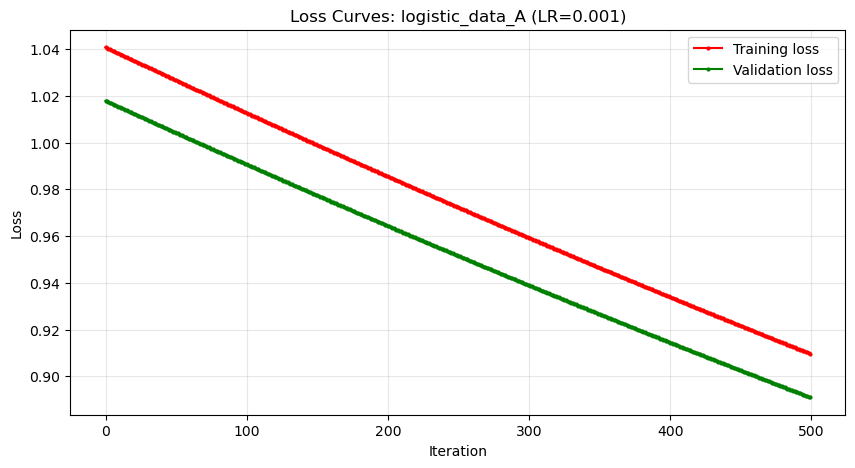

Saved loss curve to: result\plots\logistic\logistic_data_A_lr_0.001_loss_curve.png


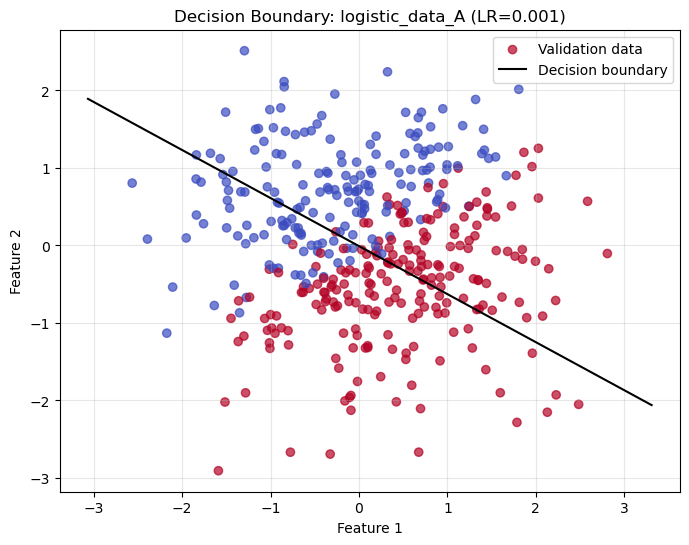

Saved decision boundary to: result\plots\logistic\logistic_data_A_lr_0.001_decision_boundary.png

Processing logistic_data_B (size=2000, dim=2)
50. Training loss: 0.5103175622043802, Val loss:0.5083432819772871
100. Training loss: 0.4370955155097443, Val loss:0.4380558711885709
150. Training loss: 0.41557622016883045, Val loss:0.41686490530445874
200. Training loss: 0.4064609166991815, Val loss:0.40772460423377516
250. Training loss: 0.40189820214342353, Val loss:0.403075856575893
300. Training loss: 0.39939491697142937, Val loss:0.4004811213417746
350. Training loss: 0.39794090751624056, Val loss:0.3989428914867826
400. Training loss: 0.3970632739456962, Val loss:0.3979910069463985
450. Training loss: 0.39651887299277666, Val loss:0.39738238093902234
500. Training loss: 0.39617431232724015, Val loss:0.39698286902644125


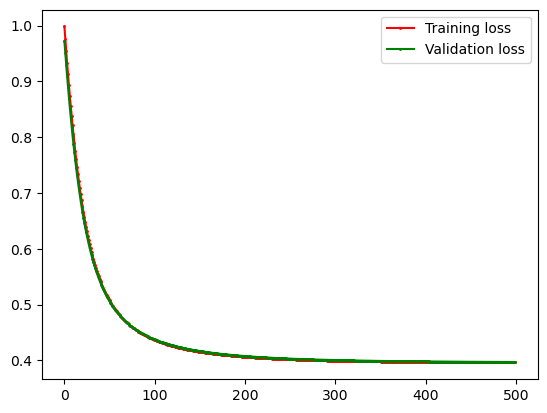

logistic_data_B - Learning Rate: 0.1
Accuracy  : 0.7800
Precision : 0.7793
Recall    : 0.8160
F1-score  : 0.7972


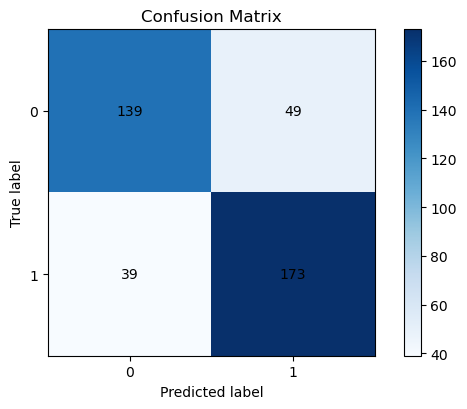

Saved confusion matrix to: result\plots\logistic\logistic_data_B_lr_0.1_confusion_matrix.png


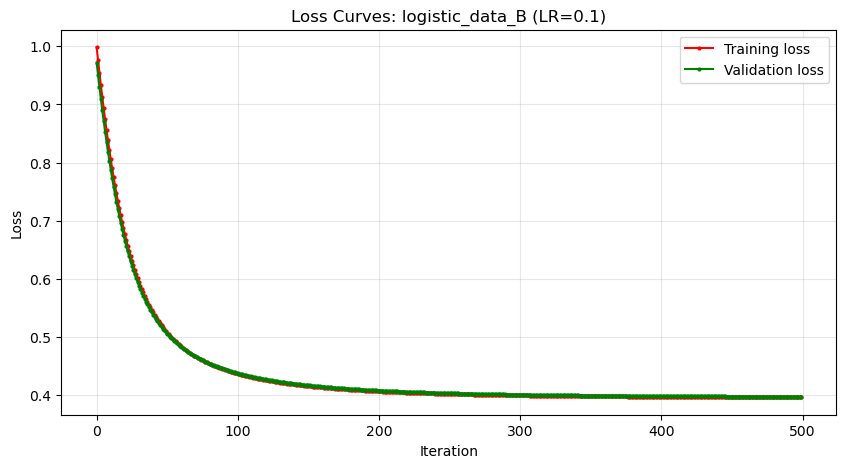

Saved loss curve to: result\plots\logistic\logistic_data_B_lr_0.1_loss_curve.png


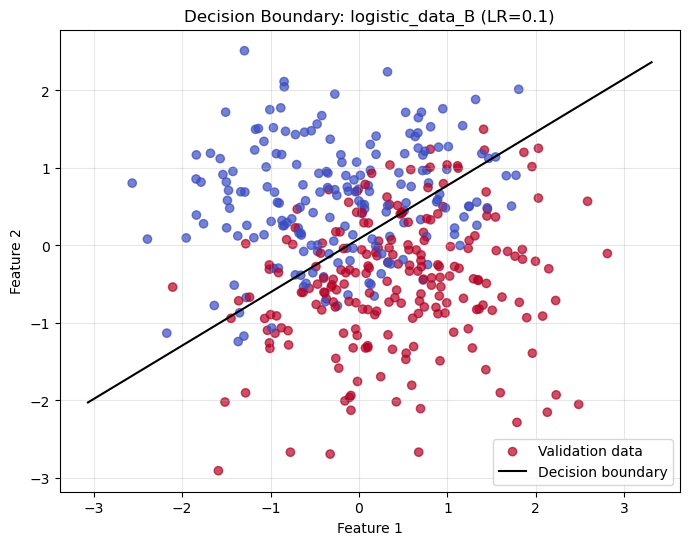

Saved decision boundary to: result\plots\logistic\logistic_data_B_lr_0.1_decision_boundary.png
50. Training loss: 0.8957410640363592, Val loss:0.8906374105058227
100. Training loss: 0.8083096467352318, Val loss:0.804210107205688
150. Training loss: 0.7369603264945954, Val loss:0.7337661725077593
200. Training loss: 0.6795500174801885, Val loss:0.6771732291658011
250. Training loss: 0.6336948605195072, Val loss:0.6320453148336889
300. Training loss: 0.5971080713785597, Val loss:0.5960905942359478
350. Training loss: 0.5678011822962918, Val loss:0.567319509722204
400. Training loss: 0.5441528833412147, Val loss:0.5441156176252377
450. Training loss: 0.5248927073071165, Val loss:0.5252178109592448
500. Training loss: 0.5090467133965937, Val loss:0.5096635682600803


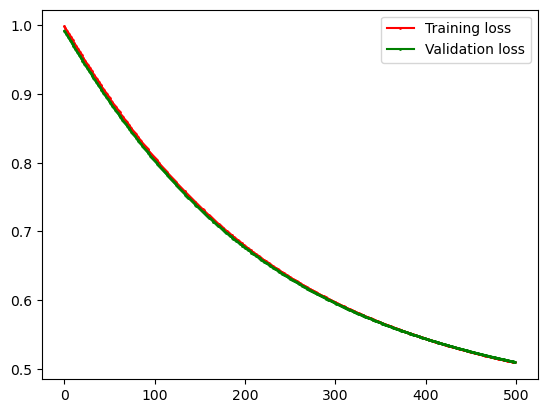

logistic_data_B - Learning Rate: 0.01
Accuracy  : 0.7625
Precision : 0.7600
Recall    : 0.8066
F1-score  : 0.7826


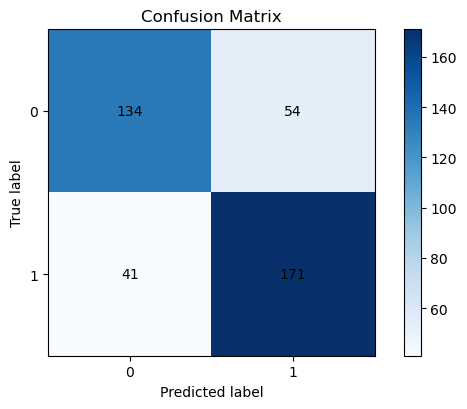

Saved confusion matrix to: result\plots\logistic\logistic_data_B_lr_0.01_confusion_matrix.png


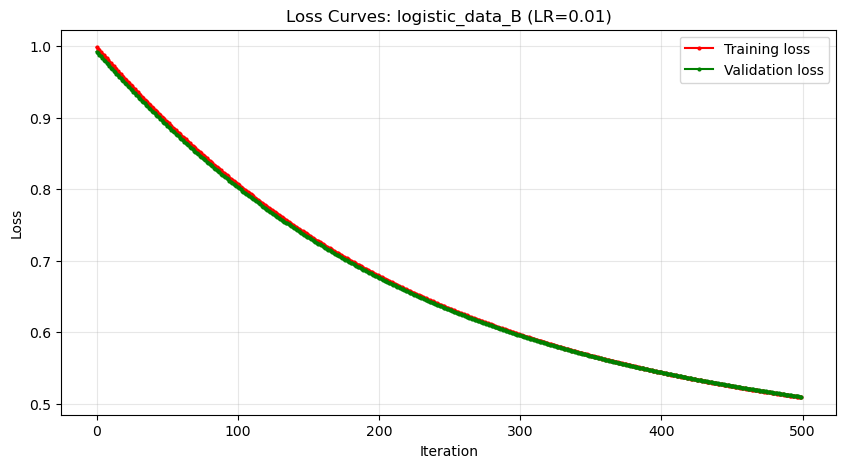

Saved loss curve to: result\plots\logistic\logistic_data_B_lr_0.01_loss_curve.png


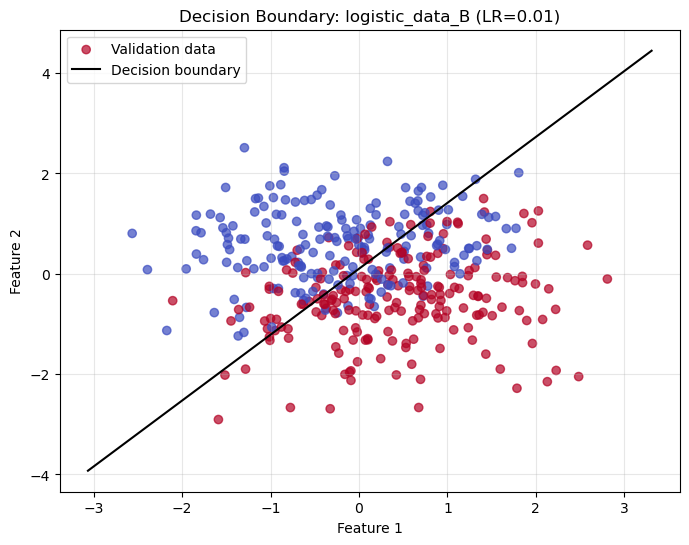

Saved decision boundary to: result\plots\logistic\logistic_data_B_lr_0.01_decision_boundary.png
50. Training loss: 0.9874379008463233, Val loss:0.9833381665312408
100. Training loss: 0.9763421106130918, Val loss:0.9723285004243568
150. Training loss: 0.9654284713499056, Val loss:0.9614993121069905
200. Training loss: 0.9546966109038486, Val loss:0.9508503118676399
250. Training loss: 0.9441460548822513, Val loss:0.9403811053688884
300. Training loss: 0.9337762268335361, Val loss:0.9300911936941738
350. Training loss: 0.9235864487116807, Val loss:0.9199799736931847
400. Training loss: 0.9135759416259137, Val loss:0.9100467386272083
450. Training loss: 0.9037438268754272, Val loss:0.900290679113813
500. Training loss: 0.8940891272670412, Val loss:0.8907108843683351


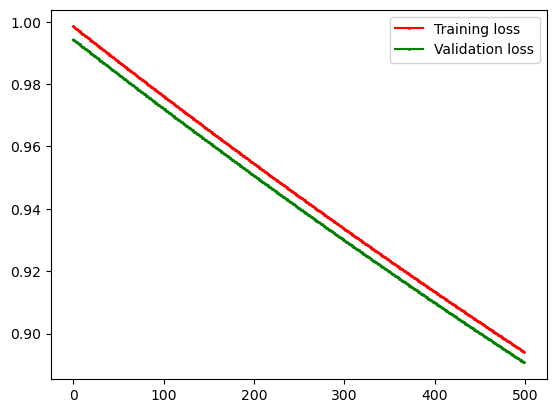

logistic_data_B - Learning Rate: 0.001
Accuracy  : 0.3925
Precision : 0.4286
Recall    : 0.4387
F1-score  : 0.4336


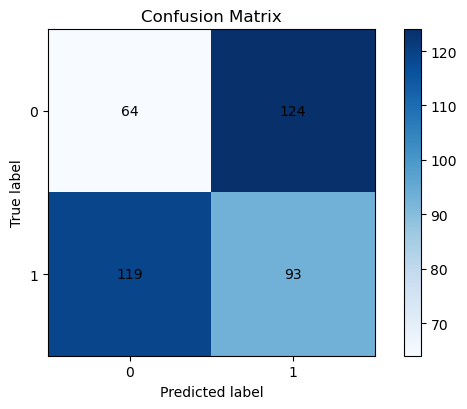

Saved confusion matrix to: result\plots\logistic\logistic_data_B_lr_0.001_confusion_matrix.png


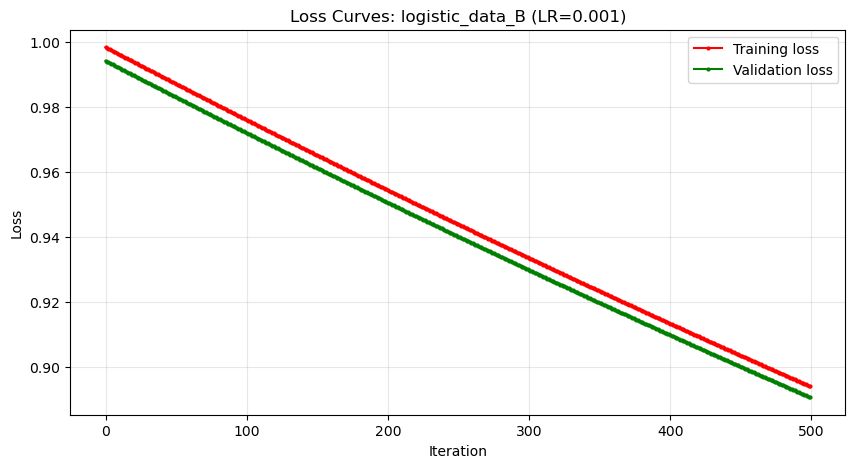

Saved loss curve to: result\plots\logistic\logistic_data_B_lr_0.001_loss_curve.png


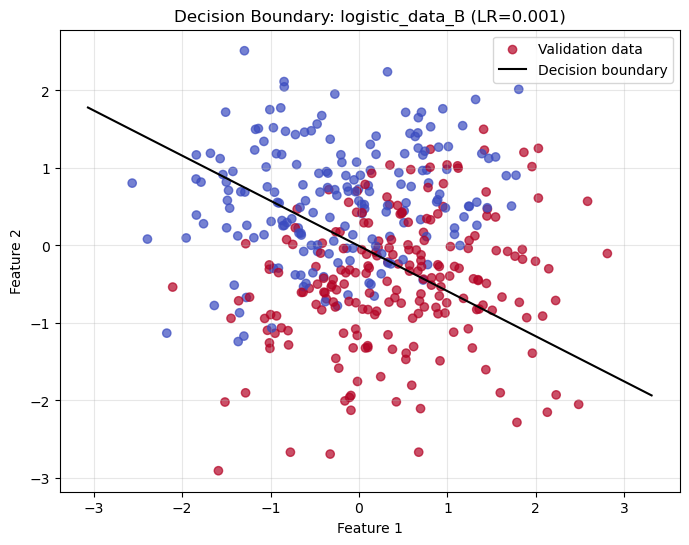

Saved decision boundary to: result\plots\logistic\logistic_data_B_lr_0.001_decision_boundary.png

Processing logistic_data_C (size=8000, dim=5)
50. Training loss: 0.2914041500436064, Val loss:0.30461404403017917
100. Training loss: 0.24213528492723757, Val loss:0.2580888835834869
150. Training loss: 0.21536654598435145, Val loss:0.2322484565856379
200. Training loss: 0.19747326685613661, Val loss:0.21464876637946464
250. Training loss: 0.18425966445090686, Val loss:0.20146358893625357
300. Training loss: 0.17392662515639434, Val loss:0.19104062396513338
350. Training loss: 0.1655356333407847, Val loss:0.18250642396014666
400. Training loss: 0.15853434715164158, Val loss:0.17533939085232825
450. Training loss: 0.1525707400848272, Val loss:0.1692025922688029
500. Training loss: 0.14740737629117942, Val loss:0.1638661602105938


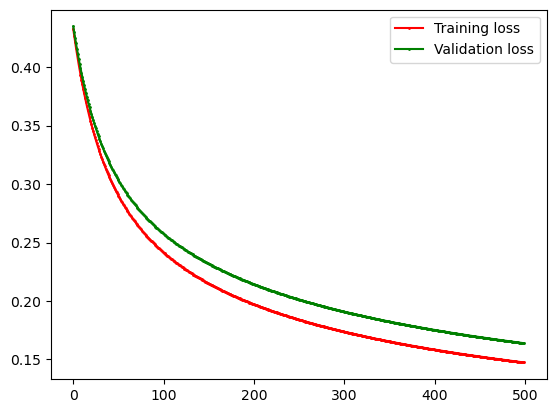

logistic_data_C - Learning Rate: 0.1
Accuracy  : 0.9762
Precision : 0.9852
Recall    : 0.9719
F1-score  : 0.9785


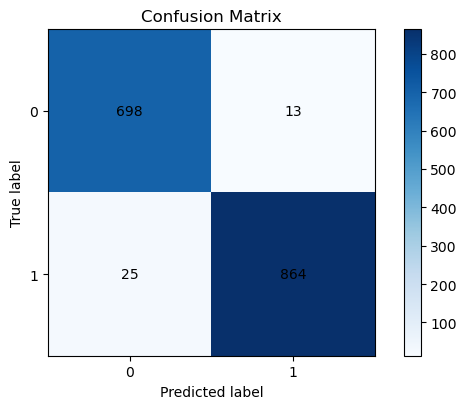

Saved confusion matrix to: result\plots\logistic\logistic_data_C_lr_0.1_confusion_matrix.png


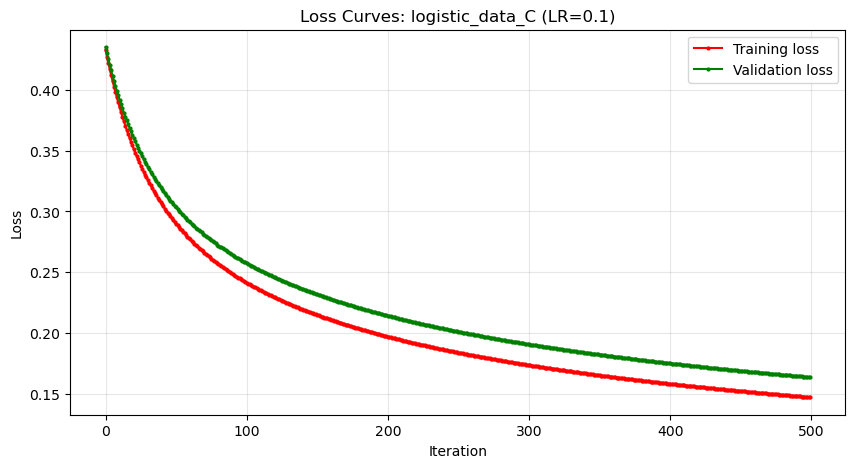

Saved loss curve to: result\plots\logistic\logistic_data_C_lr_0.1_loss_curve.png


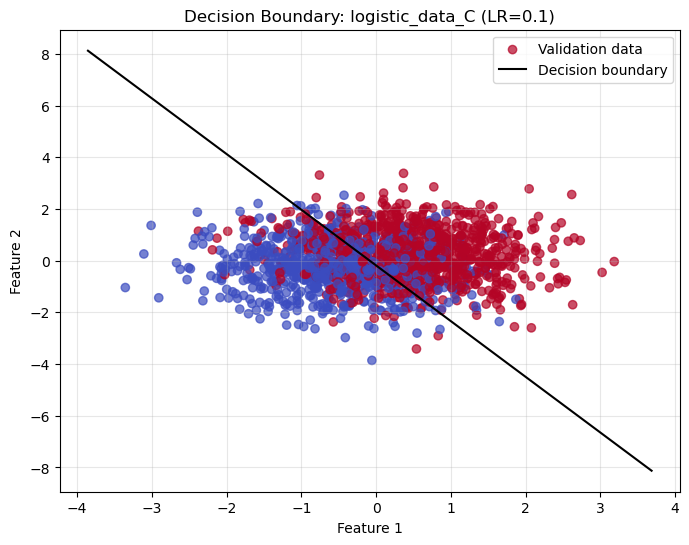

Saved decision boundary to: result\plots\logistic\logistic_data_C_lr_0.1_decision_boundary.png
50. Training loss: 0.40763335808873047, Val loss:0.41596249839320293
100. Training loss: 0.3860913696555631, Val loss:0.3956206679931872
150. Training loss: 0.3677333549357604, Val loss:0.37826386485051927
200. Training loss: 0.35195423947335824, Val loss:0.36332831682999583
250. Training loss: 0.33827534357025274, Val loss:0.3503673663467325
300. Training loss: 0.32631769333124555, Val loss:0.3390266190729544
350. Training loss: 0.31578039047898315, Val loss:0.32902400827673756
400. Training loss: 0.3064235064986363, Val loss:0.3201340925514732
450. Training loss: 0.29805473954887807, Val loss:0.3121758074752029
500. Training loss: 0.2905190785492918, Val loss:0.30500295447302056


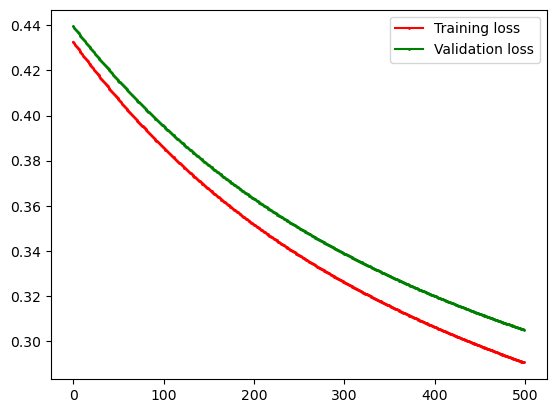

logistic_data_C - Learning Rate: 0.01
Accuracy  : 0.9456
Precision : 0.9707
Recall    : 0.9303
F1-score  : 0.9500


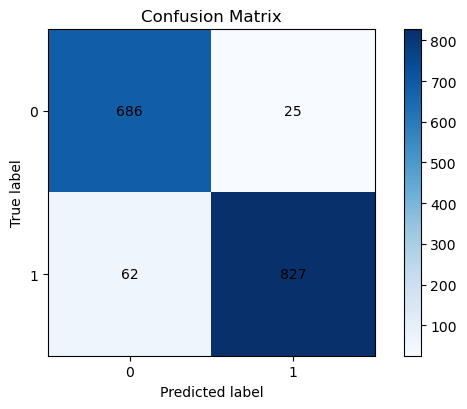

Saved confusion matrix to: result\plots\logistic\logistic_data_C_lr_0.01_confusion_matrix.png


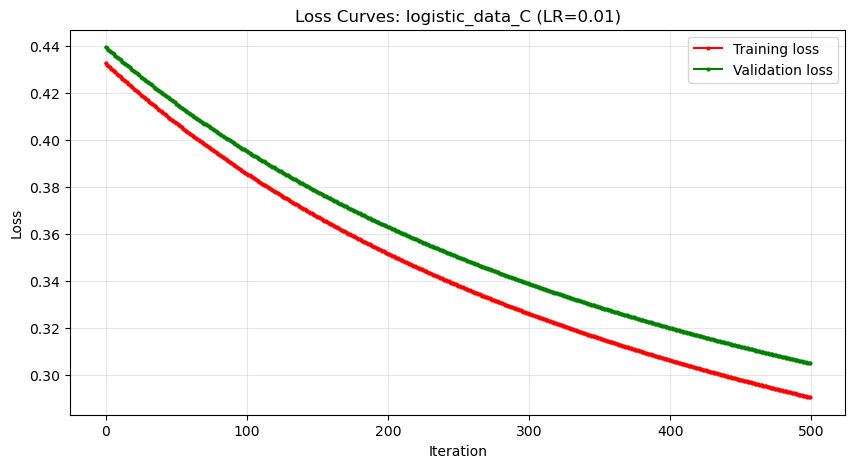

Saved loss curve to: result\plots\logistic\logistic_data_C_lr_0.01_loss_curve.png


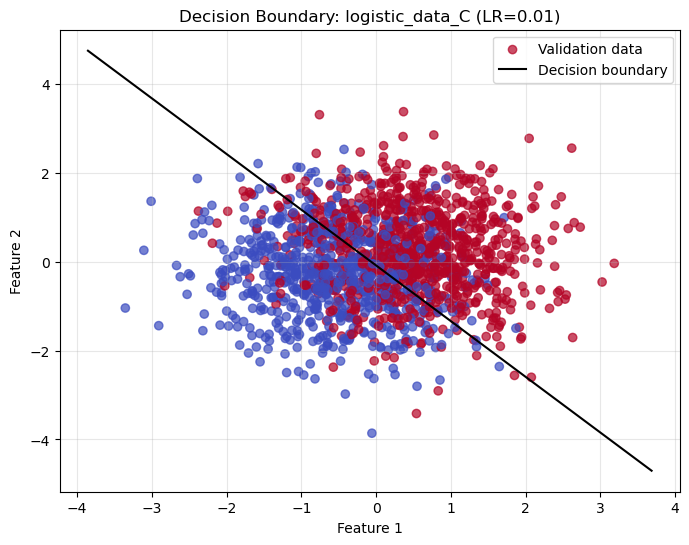

Saved decision boundary to: result\plots\logistic\logistic_data_C_lr_0.01_decision_boundary.png
50. Training loss: 0.4298821030676496, Val loss:0.43740830867066577
100. Training loss: 0.4271883654785384, Val loss:0.43486105109553536
150. Training loss: 0.42454112656343235, Val loss:0.4323574765831896
200. Training loss: 0.42193938784995444, Val loss:0.42989664927305665
250. Training loss: 0.4193821724637837, Val loss:0.4274776538321253
300. Training loss: 0.41686852479007863, Val loss:0.4250995951031024
350. Training loss: 0.41439751012942966, Val loss:0.42276159774950733
400. Training loss: 0.4119682143493205, Val loss:0.4204628058985884
450. Training loss: 0.40957974353201126, Val loss:0.41820238278287747
500. Training loss: 0.40723122361969855, Val loss:0.4159795103811308


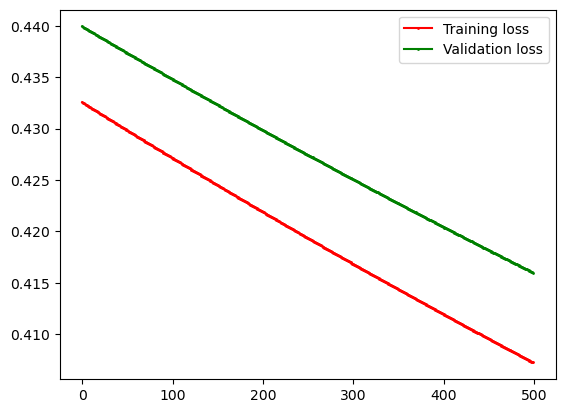

logistic_data_C - Learning Rate: 0.001
Accuracy  : 0.8406
Precision : 0.8774
Recall    : 0.8290
F1-score  : 0.8525


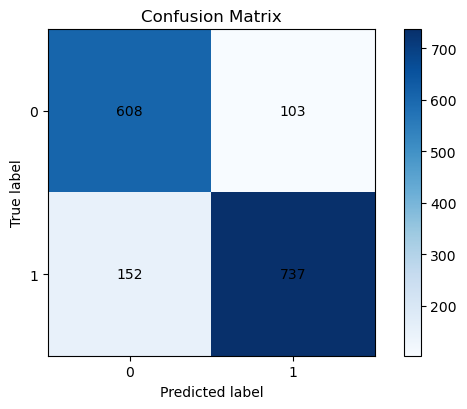

Saved confusion matrix to: result\plots\logistic\logistic_data_C_lr_0.001_confusion_matrix.png


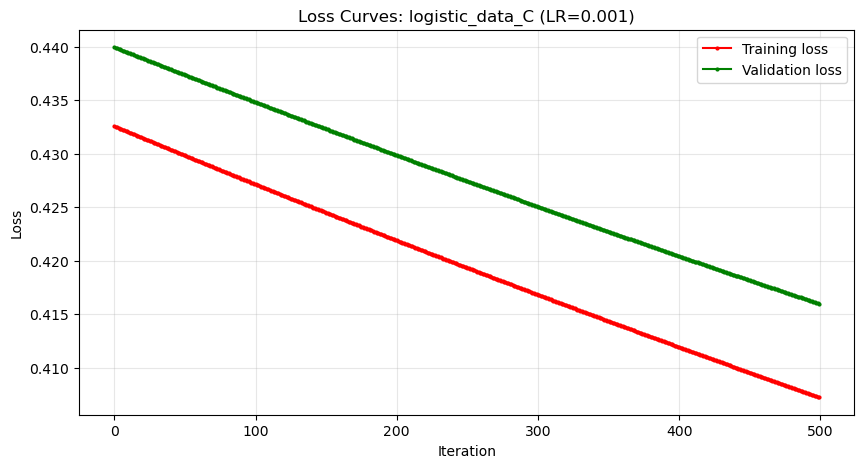

Saved loss curve to: result\plots\logistic\logistic_data_C_lr_0.001_loss_curve.png


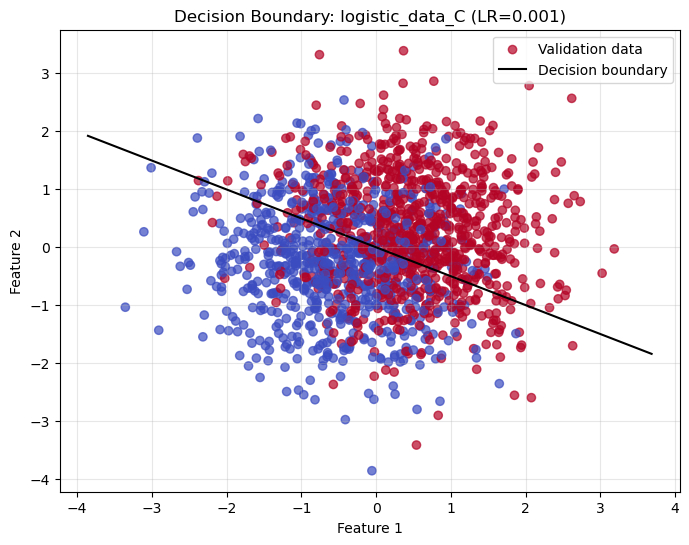

Saved decision boundary to: result\plots\logistic\logistic_data_C_lr_0.001_decision_boundary.png

Processing logistic_data_D (size=8000, dim=5)
50. Training loss: 0.31214565926023174, Val loss:0.3238995705537948
100. Training loss: 0.2680253579500514, Val loss:0.2845901168491454
150. Training loss: 0.24507991801016674, Val loss:0.2636714373900576
200. Training loss: 0.23025970529698733, Val loss:0.24981367489682632
250. Training loss: 0.21963615020155505, Val loss:0.23967468756947913
300. Training loss: 0.2115547767275018, Val loss:0.2318441744405014
350. Training loss: 0.20516346620008113, Val loss:0.22558274853425692
400. Training loss: 0.19996566773456392, Val loss:0.22044961112666256
450. Training loss: 0.195647628340575, Val loss:0.21616005232291835
500. Training loss: 0.19199945372601435, Val loss:0.21251993712270317


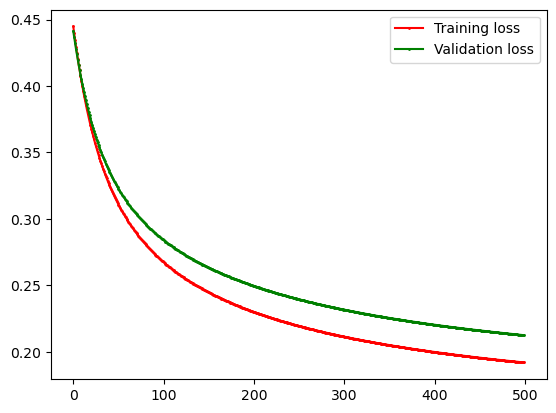

logistic_data_D - Learning Rate: 0.1
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


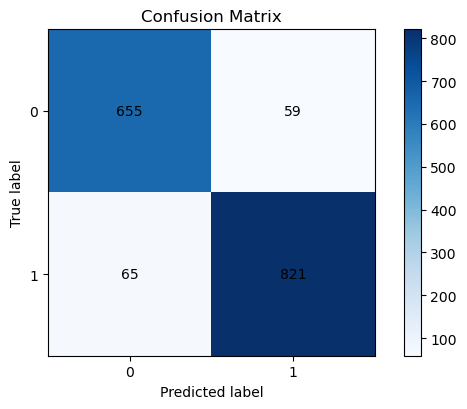

Saved confusion matrix to: result\plots\logistic\logistic_data_D_lr_0.1_confusion_matrix.png


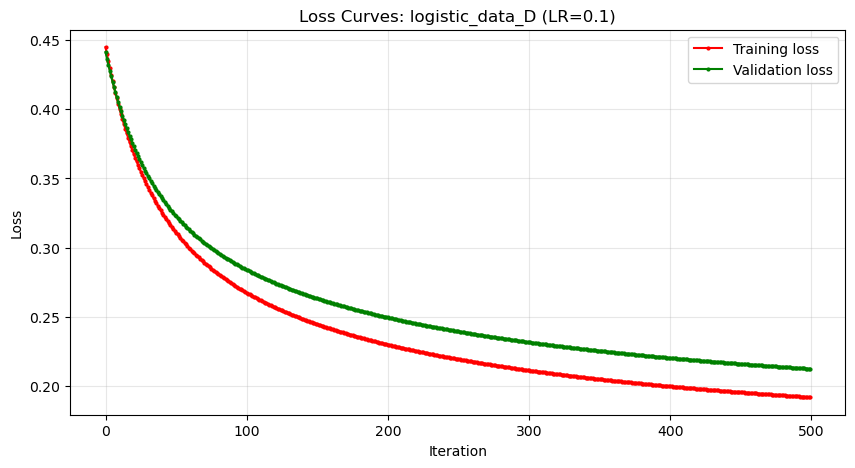

Saved loss curve to: result\plots\logistic\logistic_data_D_lr_0.1_loss_curve.png


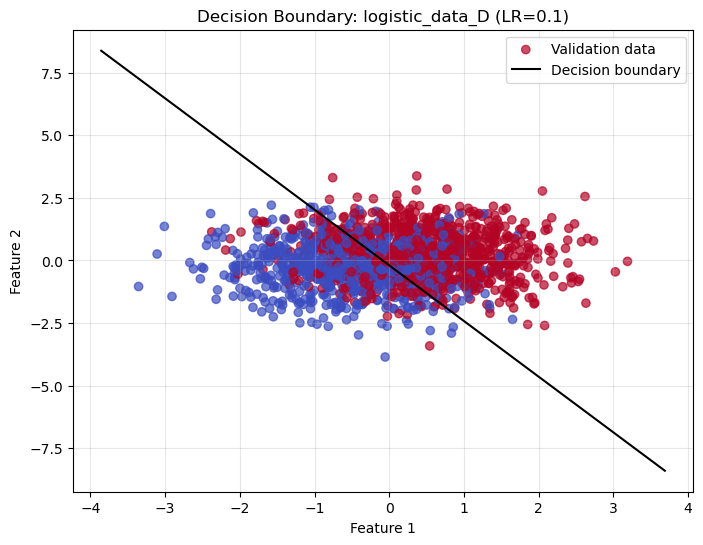

Saved decision boundary to: result\plots\logistic\logistic_data_D_lr_0.1_decision_boundary.png
50. Training loss: 0.4210863364107005, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.40526939422934116
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.3444310989408412, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.3113486162459987, Val loss:0.3242394100832966


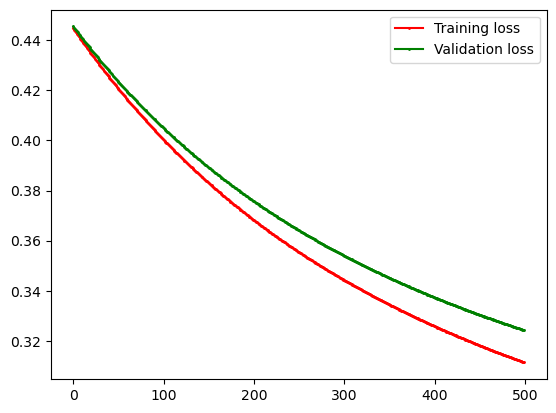

logistic_data_D - Learning Rate: 0.01
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


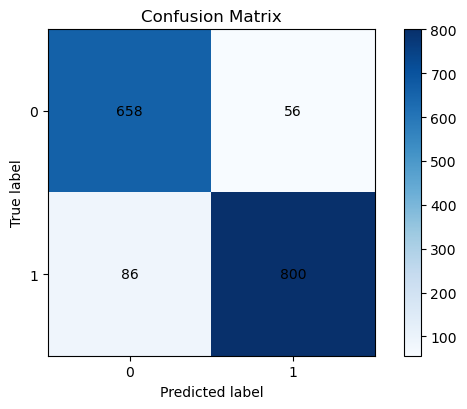

Saved confusion matrix to: result\plots\logistic\logistic_data_D_lr_0.01_confusion_matrix.png


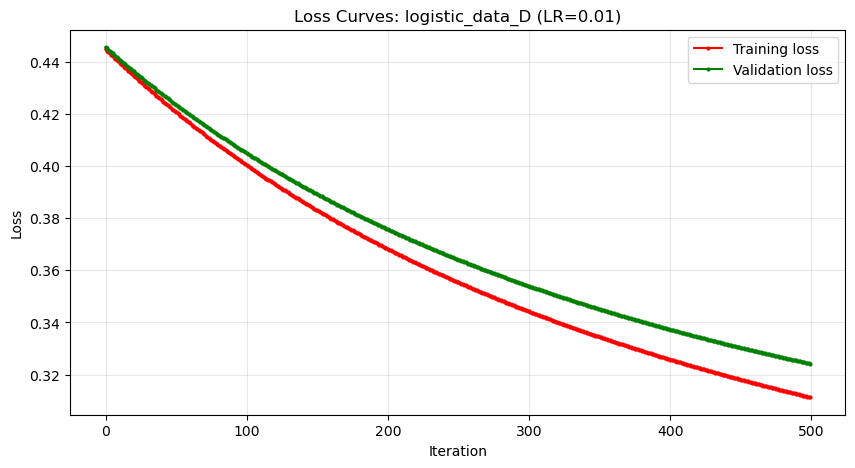

Saved loss curve to: result\plots\logistic\logistic_data_D_lr_0.01_loss_curve.png


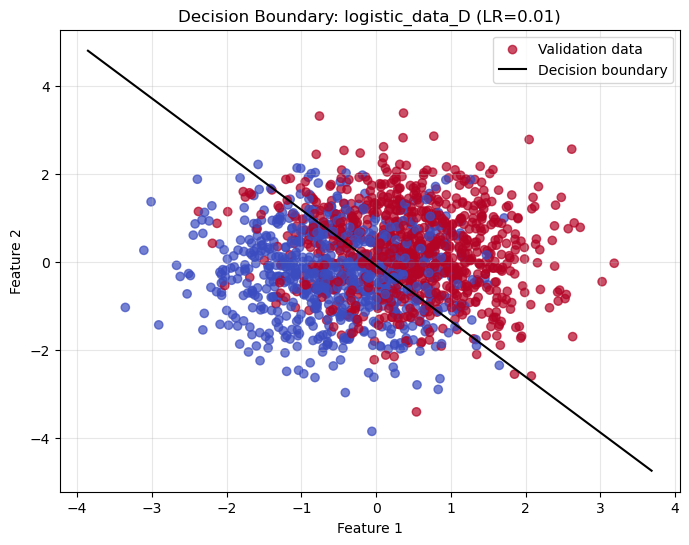

Saved decision boundary to: result\plots\logistic\logistic_data_D_lr_0.01_decision_boundary.png
50. Training loss: 0.44221977024873604, Val loss:0.4436168074363421
100. Training loss: 0.4396594302179652, Val loss:0.4412701641807759
150. Training loss: 0.4371436725613986, Val loss:0.43896472084268623
200. Training loss: 0.4346715536135045, Val loss:0.4366996003801621
250. Training loss: 0.4322421495919633, Val loss:0.43447394458012223
300. Training loss: 0.4298545563023576, Val loss:0.43228691374881156
350. Training loss: 0.42750788883734553, Val loss:0.43013768639915717
400. Training loss: 0.42520128127118983, Val loss:0.4280254589357611
450. Training loss: 0.4229338863504631, Val loss:0.4259494453382512
500. Training loss: 0.42070487518169253, Val loss:0.42390887684365186


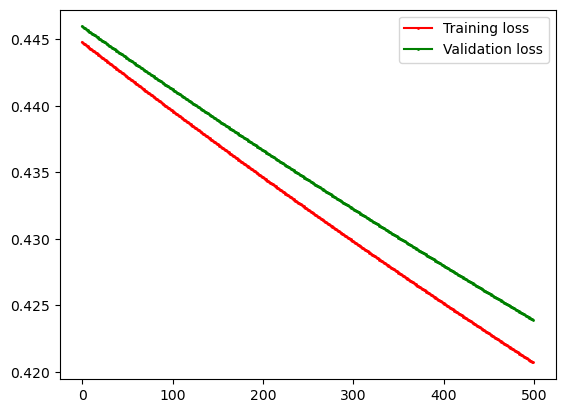

logistic_data_D - Learning Rate: 0.001
Accuracy  : 0.8319
Precision : 0.8668
Recall    : 0.8228
F1-score  : 0.8442


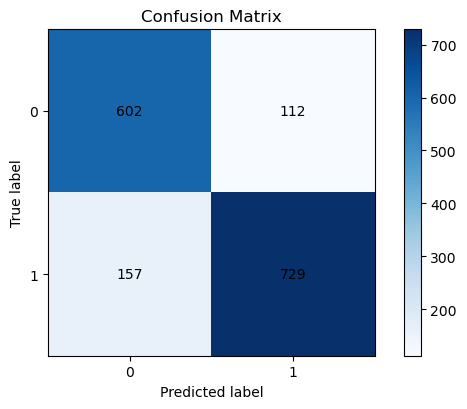

Saved confusion matrix to: result\plots\logistic\logistic_data_D_lr_0.001_confusion_matrix.png


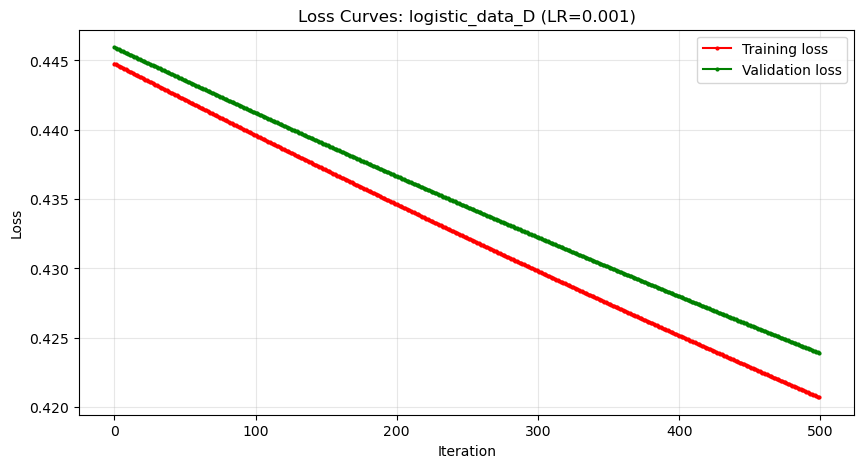

Saved loss curve to: result\plots\logistic\logistic_data_D_lr_0.001_loss_curve.png


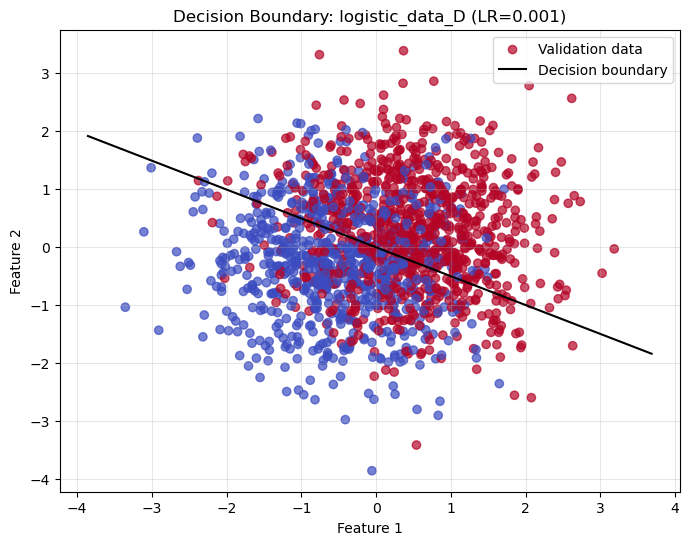

Saved decision boundary to: result\plots\logistic\logistic_data_D_lr_0.001_decision_boundary.png

Summary metrics saved to: result\metrics\summary_metrics_logistic.json


In [3]:
# Train and evaluate every dataset with each learning rate
seed = 42  # do not change the seed
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

for dataset_path in dataset_files:
    dataset_name = Path(dataset_path).stem

    loaded_data = np.load(dataset_path)
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']

    size = X.shape[0]
    dim = X.shape[1] - 1

    print(f"\n{'=' * 70}")
    print(f"Processing {dataset_name} (size={size}, dim={dim})")
    print(f"{'=' * 70}")

    all_results[dataset_name] = {}

    for lr in learning_rates:
        np.random.seed(seed)
        X_train, y_train, X_val, y_val = get_train_val(X, y)

        model = LinearModel(dim, False, loss_fn, grad_fn, act_fn)
        model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

        y_val_pred_prob = model.predict(X_val)
        y_val_pred = (y_val_pred_prob >= 0.5).astype(int)

        title = f'{dataset_name} - Learning Rate: {lr}'
        metrics = evaluate_binary_classifier(
            y_true=y_val,
            y_pred=y_val_pred,
            title=title
        )
        cm_filename = plot_dir / f'{dataset_name}_lr_{lr}_confusion_matrix.png'
        cm_fig = plt.gcf()
        cm_fig.savefig(cm_filename, dpi=100, bbox_inches='tight')
        plt.close(cm_fig)
        print(f"Saved confusion matrix to: {cm_filename}")

        all_results[dataset_name][f'lr_{lr}'] = metrics

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(range(len(model.train_losses)), model.train_losses, 'o-', color='r', label='Training loss', markersize=2)
        ax.plot(range(len(model.val_losses)), model.val_losses, 'o-', color='g', label='Validation loss', markersize=2)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_title(f'Loss Curves: {dataset_name} (LR={lr})')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        loss_filename = plot_dir / f'{dataset_name}_lr_{lr}_loss_curve.png'
        fig.savefig(loss_filename, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"Saved loss curve to: {loss_filename}")

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(X_val[:, 1], X_val[:, 2], c=y_val, cmap='coolwarm', alpha=0.7, label='Validation data')
        ex1 = np.linspace(X_val[:, 1].min() - 0.5, X_val[:, 1].max() + 0.5, 200)
        ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]
        ax.plot(ex1, ex2, color='black', label='Decision boundary')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_title(f'Decision Boundary: {dataset_name} (LR={lr})')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        boundary_filename = plot_dir / f'{dataset_name}_lr_{lr}_decision_boundary.png'
        fig.savefig(boundary_filename, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"Saved decision boundary to: {boundary_filename}")

summary_file = metric_dir / 'summary_metrics_logistic.json'
with open(summary_file, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2)

print(f"\nSummary metrics saved to: {summary_file}")